## **Test model**

In [2]:
import pandas as pd
import torch

from config import OUT_DIR
from src.Model import InfernoCalibNet
from src.Dataset import ChestXRayDataset

from torch.utils.data import DataLoader

def evaluate_and_prepare_inferno():
    torch.cuda.empty_cache()

    df_meta = pd.read_csv(OUT_DIR / "ml_test.csv")
    test_dt = ChestXRayDataset(OUT_DIR / "ml_test.csv", transform=False)
    test_loader = DataLoader(
        test_dt, batch_size=32, shuffle=False, num_workers=8, pin_memory=True
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(OUT_DIR / "InfernoCalibNetML.pth", weights_only=True))
    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            all_preds.append(outputs.cpu())
            all_targets.append(targets.cpu())

    preds_tensor = torch.cat(all_preds)
    targets_tensor = torch.cat(all_targets)

    df_meta = df_meta.reset_index(drop=True)
    df_meta["LOGIT_EFFUSION"] = preds_tensor[:, 0].numpy()
    df_meta["LABEL_EFFUSION"] = targets_tensor[:, 0].numpy().astype(int)
    df_meta["LOGIT_ATELECTASIS"] = preds_tensor[:, 1].numpy()
    df_meta["LABEL_ATELECTASIS"] = targets_tensor[:, 1].numpy().astype(int)

    df_meta.to_csv(OUT_DIR / "inferno" / "calibration_full.csv", index=False)

    loss_fn = torch.nn.BCEWithLogitsLoss()
    total_loss = loss_fn(preds_tensor, targets_tensor).item()

    return df_meta, preds_tensor, targets_tensor, total_loss

def stratified_sample(df, label_col, sample_size, seed=42):
    from sklearn.model_selection import train_test_split

    stratified_df, remainder_df = train_test_split(
        df,
        train_size=sample_size,
        stratify=df[label_col],
        random_state=seed
    )
    return stratified_df, remainder_df

df, preds, targets, loss = evaluate_and_prepare_inferno()
sampled_df, remainder_df = stratified_sample(df, label_col="LABEL_EFFUSION", sample_size=1500)
sampled_df.to_csv(OUT_DIR / "inferno" / "calibration_train.csv", index=False)
remainder_df.to_csv(OUT_DIR / "inferno" / "calibration_test.csv", index=False)


─────────────────────────────────────────────── Evaluation Metrics ────────────────────────────────────────────────

Test BCEWithLogitsLoss: 0.4423

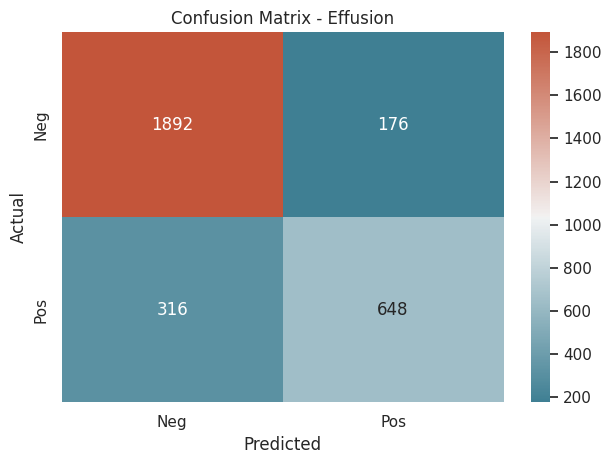

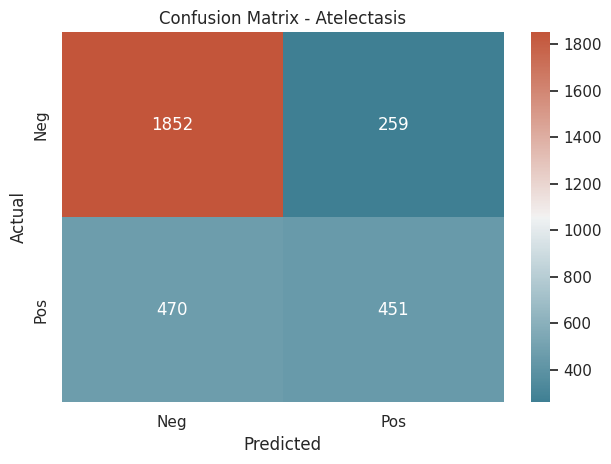

                         Classification Metrics                         
┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃    Label    ┃ Precision ┃ Recall ┃ F1-score ┃  AUROC ┃ Avg Precision ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━┩
│  Effusion   │    0.7864 │ 0.6722 │   0.7248 │ 0.8901 │        0.7829 │
├─────────────┼───────────┼────────┼──────────┼────────┼───────────────┤
│ Atelectasis │    0.6352 │ 0.4897 │   0.5530 │ 0.7892 │        0.6263 │
└─────────────┴───────────┴────────┴──────────┴────────┴───────────────┘

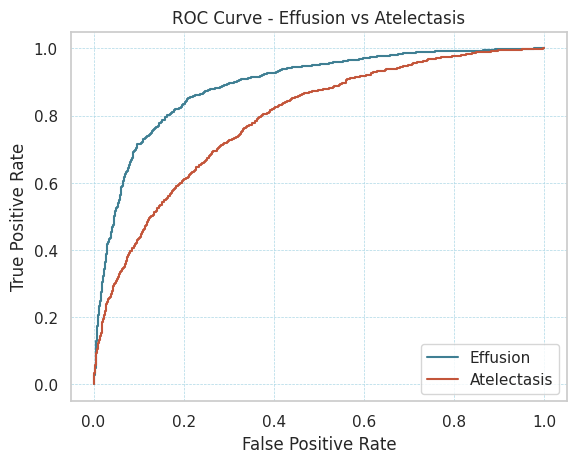

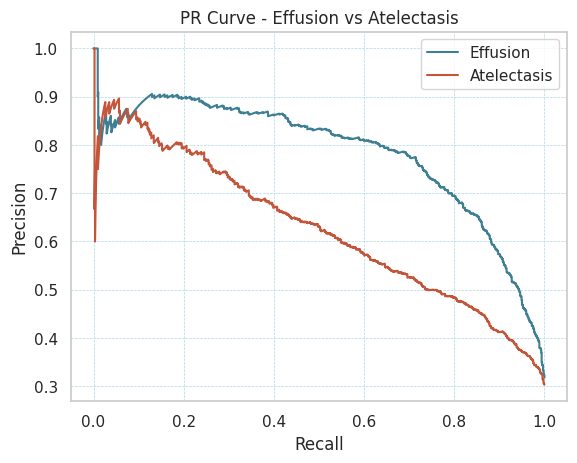

In [8]:
from rich.console import Console
from rich.table import Table

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

sns.set_theme(style="whitegrid", palette=sns.diverging_palette(220, 20, n=2))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

console = Console()

def runMetrics(preds_tensor, targets_tensor, avg_loss):
    probs = torch.sigmoid(preds_tensor).numpy()
    targets = targets_tensor.numpy()

    console.rule("[bold cyan]Evaluation Metrics")
    console.print(f"Test BCEWithLogitsLoss: {avg_loss:.4f}")

    table = Table(title="Classification Metrics", show_lines=True)
    table.add_column("Label", justify="center")
    table.add_column("Precision", justify="right")
    table.add_column("Recall", justify="right")
    table.add_column("F1-score", justify="right")
    table.add_column("AUROC", justify="right")
    table.add_column("Avg Precision", justify="right")

    roc_data = {}
    pr_data = {}

    for i, label_name in zip([0, 1], ["Effusion", "Atelectasis"]):
        p = probs[:, i] > 0.5
        t = targets[:, i]

        prec = precision_score(t, p)
        rec = recall_score(t, p)
        f1 = f1_score(t, p)
        auroc = roc_auc_score(t, probs[:, i])
        ap = average_precision_score(t, probs[:, i])

        table.add_row(label_name, f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", f"{auroc:.4f}", f"{ap:.4f}")

        fpr, tpr, _ = roc_curve(t, probs[:, i])
        prec_curve, rec_curve, _ = precision_recall_curve(t, probs[:, i])

        roc_data[label_name] = (fpr, tpr)
        pr_data[label_name] = (rec_curve, prec_curve)

        cm = confusion_matrix(t, p)
        plt.figure()
        sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"])
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - {label_name}")
        plt.grid(False)
        plt.tight_layout()
        plt.show()

    console.print(table)

    plt.figure()
    for label, (fpr, tpr) in roc_data.items():
        plt.plot(fpr, tpr, label=label)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Effusion vs Atelectasis")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, color='lightblue')
    plt.show()

    plt.figure()
    for label, (rec_curve, prec_curve) in pr_data.items():
        plt.plot(rec_curve, prec_curve, label=label)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("PR Curve - Effusion vs Atelectasis")
    plt.legend()
    plt.grid(True, linestyle='--', linewidth=0.5, color='lightblue')
    plt.show()

runMetrics(preds, targets, loss)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def runGradCAM(model, input_tensor):
    model.eval()
    target_layer = model.base_model[-1]  # last conv layer before classifier

    cam = GradCAM(model=model, target_layers=[target_layer])

    input_tensor = input_tensor.unsqueeze(0)
    input_tensor.requires_grad = True

    with torch.no_grad():
        output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(predicted_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    grayscale_cam = np.maximum(grayscale_cam, 0)
    grayscale_cam = grayscale_cam - grayscale_cam.min()
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    img = input_tensor.detach().cpu().squeeze().numpy()
    fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray")
    ax.imshow(grayscale_cam, cmap="jet", alpha=0.5)
    ax.set_title(f"Grad-CAM for predicted class {predicted_class}")
    plt.axis("off")
    plt.show()

torch.cuda.empty_cache()
test_dt = ChestXRayDataset(OUT_DIR / "ml_test.csv", transform=False)
test_loader = DataLoader(
    test_dt, batch_size=64, shuffle=False, num_workers=8, pin_memory=True
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InfernoCalibNet(num_classes=2).to(device)
model.load_state_dict(torch.load(OUT_DIR / "InfernoCalibNetML.pth", weights_only=True))
example_input = next(iter(test_loader))[0][62].to(device)
runGradCAM(model, example_input)
